# ML from DFT data

In [1]:
from sqlite3 import OptimizedUnicode
from unittest.mock import inplace
import matplotlib.pyplot as plt
import pandas as pd
from pygments.lexer import this
#from scipy.io._test_fortran import __test_fortran_error
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.DatasetTools.Commoms import *
from matplotlib.patches import Patch
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
from Tools.DatasetTools.MLConveniences import *
from matplotlib.path import Path

/tmp/ipykernel_58886/2233343438.py:1: DeprecationWarning: 
            OptimizedUnicode is deprecated and will be removed in Python 3.12.
            Since Python 3.3 it has simply been an alias for 'str'.
        
  from sqlite3 import OptimizedUnicode
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=18)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=22)
from matplotlib.lines import Line2D

In [3]:
figwidth, figheight = plt.rcParams['figure.figsize']

# Parameters 

In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784
Mo_sv6.C15.NM,bulk C15,16.457210 A,-10.565358,234.041146 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.014,0,1,...,6,0,6,0.000000,1.000000,NM,C15,0.367463,0.367463,0.367463


# Targets

Text(0.5, 0, '$V_0$')

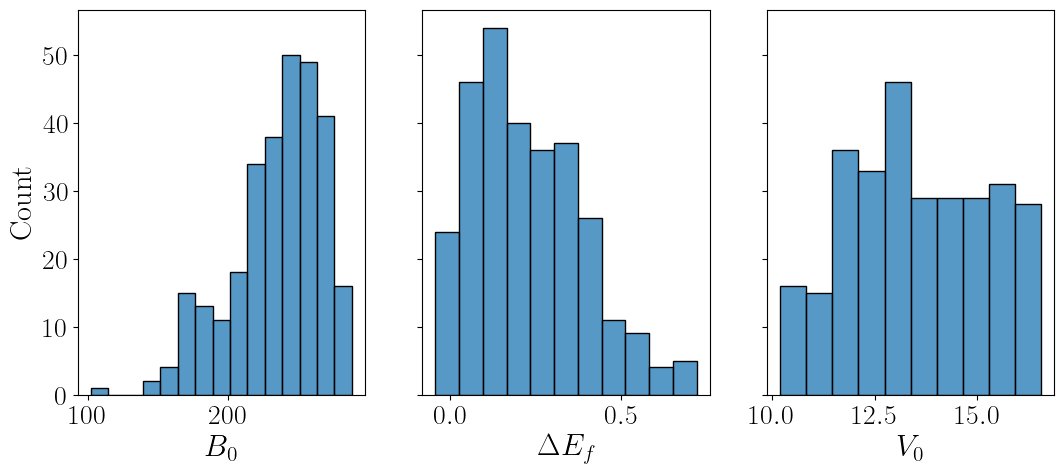

In [7]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(1,3, figsize=(3*figwidth*(3/5), figheight), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,...,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,-6.925199,-6.050627,0.0,0.000000,0.000000,-0.874571,0.689619,0.571110,...,0.390118,1.081732,1.156282,0.0,0.000000,0.000000,0.901327,-82.472282,-84.309469,0.183094
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,-7.069580,-2.079584,0.0,-0.750946,-0.317244,-3.921805,0.690493,0.433446,...,0.137907,1.192249,1.343511,0.0,1.139857,0.956735,0.947607,-186.101697,-189.259613,0.560660
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,-6.601047,-2.125589,0.0,-3.588088,-0.477620,-0.409750,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.507368
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,-6.958838,-1.238417,0.0,-5.296760,-0.423661,0.000000,0.658999,0.243336,...,0.000000,1.224173,1.311938,0.0,1.187306,1.155462,0.000000,-106.073592,-106.249550,0.556429
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,-6.566157,-2.087629,0.0,-0.512510,-0.374860,-3.591159,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.004543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,2,1,-9.770953,-7.688316,0.0,0.000000,0.000000,-2.082637,1.635499,0.957173,...,0.618375,1.069390,1.032624,0.0,0.000000,0.000000,1.135754,-32.035307,-32.436815,0.629768
Mo_sv1.bcc.NM,5,0,-3.130925,0.000000,0.0,-3.130925,0.000000,0.000000,0.491648,0.000000,...,0.000000,1.261308,0.000000,0.0,1.261308,0.000000,0.000000,-3.130925,-3.130925,0.405370
Mo_sv8.A15.NM,0,0,-5.978096,-3.583571,0.0,-2.394525,0.000000,0.000000,0.531115,0.136149,...,0.000000,1.195488,1.177466,0.0,1.201725,0.000000,0.000000,-25.446069,-25.453952,0.358978
Mo_sv1.fcc.NM,7,0,-2.941773,-2.941773,0.0,0.000000,0.000000,0.000000,0.471662,0.471662,...,0.000000,1.140028,1.140028,0.0,0.000000,0.000000,0.000000,-2.941774,-2.941774,0.184495


In [11]:
for featurename in Features.keys():
    print(featurename)

atomic
dataset
SOAP_canonicalW_small
SOAP_specific_small
Pyscal
ACE
NOZERO-ACE
NOZERO_NOONE-ACE
NOZERO_NOONE_NOTWO-ACE
NOTHREE-ACE
NOTHREE-NOTWO-ACE
NOTHREE-NOTWO_NOONE-ACE
Canonical ACE
Canonical BOP
0.7dProjections 0.5OS BOP
0.7spProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
dataset + 0.7spProjections 0.5OS BOP
atomic no CNAV
dataset no CNAV
SOAP_canonicalW_small no CNAV
SOAP_specific_small no CNAV
Pyscal no CNAV
ACE no CNAV
NOZERO-ACE no CNAV
NOZERO_NOONE-ACE no CNAV
NOZERO_NOONE_NOTWO-ACE no CNAV
NOTHREE-ACE no CNAV
NOTHREE-NOTWO-ACE no CNAV
NOTHREE-NOTWO_NOONE-ACE no CNAV
Canonical ACE no CNAV
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV
dataset + 0.7spProjections 0.5OS BOP no CNAV


## test - train splits

In [12]:
samplesplit = DS.get_samplesplit()

# Optimized models

In [13]:
from Tools.DatasetTools.MLConveniences import filter_features
import joblib
dataset='Fe-Mo'

In [14]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [15]:
modelnames=[model.replace(' ','') for model in models]

In [16]:
voting_regressor_files = {modelname: os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')
                         for modelname in modelnames}

In [17]:
voting_regressor_files

{'KernelRidge': 'Fe-Mo/results/voting_regressor_KernelRidge.pkl',
 'RandomForest': 'Fe-Mo/results/voting_regressor_RandomForest.pkl',
 'MLP': 'Fe-Mo/results/voting_regressor_MLP.pkl'}

In [18]:
optimal_regressors = {}
for model in modelnames:
    optimal_regressors.update(joblib.load(voting_regressor_files[model]))

In [19]:
optimal_regressors.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Random Forest', 'atomic'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical ACE'), ('Random Forest', 'Canonical BOP'), ('Random Forest', '0.7dProjections 0.5OS BOP'), ('Random Forest', '0.7spProjections 0.5OS BOP'), ('Random Forest', 'ACE no C

In [20]:
trainsamples = DS.samplesplit['train']; testsamples = DS.samplesplit['test']

In [21]:
ytrain = {}
ytest = {}
ypredict = {}
for (modelname, featurename), optimalregressor in optimal_regressors.items():
    #if modelname == 'Kernel Ridge' and 'BOP' in featurename:
    print(modelname, featurename)
    optimalregressor.fit(Features[featurename].loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    ytrain[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['train']]),
                      index=DS.samplesplit['train']) 
    ytest[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['test']]),
                      index=DS.samplesplit['test']) 
    ypredict[(modelname, featurename)]= pd.concat([ytrain[(modelname, featurename)], ytest[(modelname, featurename)]], axis = 0)

Kernel Ridge atomic
Kernel Ridge dataset
Kernel Ridge Canonical ACE
Kernel Ridge Canonical BOP
Kernel Ridge ACE no CNAV
Kernel Ridge ACE
Kernel Ridge 0.7dProjections 0.5OS BOP
Kernel Ridge 0.7spProjections 0.5OS BOP
Kernel Ridge atomic no CNAV
Kernel Ridge dataset no CNAV
Kernel Ridge 0.7dProjections 0.5OS BOP no CNAV
Kernel Ridge 0.7spProjections 0.5OS BOP no CNAV
Kernel Ridge SOAP_specific_small
Kernel Ridge SOAP_specific_small no CNAV
Kernel Ridge Canonical ACE no CNAV
Kernel Ridge Canonical BOP no CNAV
Kernel Ridge SOAP_canonicalW_small
Kernel Ridge SOAP_canonicalW_small no CNAV
Random Forest atomic
Random Forest dataset
Random Forest Canonical ACE
Random Forest Canonical BOP
Random Forest 0.7dProjections 0.5OS BOP
Random Forest 0.7spProjections 0.5OS BOP
Random Forest ACE no CNAV
Random Forest ACE
Random Forest atomic no CNAV
Random Forest dataset no CNAV
Random Forest 0.7dProjections 0.5OS BOP no CNAV
Random Forest 0.7spProjections 0.5OS BOP no CNAV
Random Forest SOAP_specific_sm

In [22]:
P = Plotting()

In [23]:
CHULL_predict = {}
bs_phase = {}

In [24]:
phases = DS.StructureNames.unique()

In [25]:
DS.StructureNames

Fe_pv4Mo_sv20.C36-ABBBB.FM           C36
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM        R
Fe_pv2Mo_sv11.mu-BBABB.FM             mu
Fe_pv8Mo_sv22.sigma-BBBAB.NM       sigma
Fe_pv2Mo_sv11.mu-BBBBA.NM             mu
                                   ...  
Fe_pv6.C15.FM                        C15
Mo_sv1.bcc.NM                        bcc
Mo_sv8.A15.NM                        A15
Mo_sv1.fcc.NM                        fcc
Mo_sv6.C15.NM                        C15
Name: Phase, Length: 291, dtype: object

In [26]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784
Mo_sv6.C15.NM,bulk C15,16.457210 A,-10.565358,234.041146 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.014,0,1,...,6,0,6,0.000000,1.000000,NM,C15,0.367463,0.367463,0.367463


In [38]:
bs_phase.keys()

dict_keys(['C36', 'R', 'mu', 'sigma', 'C14', 'chi', 'hcp', 'bcc', 'fcc', 'C15', 'A15'])

In [46]:
for phase in phases:
    bs_phase[phase] = DS.BS.loc[DS.StructureNames.index][DS.StructureNames == phase].copy()
for ( modelname, featurename ), this_ytrain in ytrain.items():
    targetname = f'{target_name}__{featurename}__{modelname}'
    for phase in bs_phase:
        bs_phase[phase][targetname] = ypredict[(modelname, featurename)][bs_phase[phase].index]
    CHULL_predict[(modelname, featurename)] = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=target_name)
    

In [49]:
CHULL_dft = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=target_name)

In [50]:
#for (modelname, featurename), chull_predict in CHULL_predict.items():
#    break

In [51]:
#for phase, this_chull_predict in chull_predict.items():
#    break
#    

In [52]:
#    all_vertices_low = np.unique(np.hstack(this_chull_predict.simplices[this_chull_predict.good]))

In [53]:
#fig, ax = plt.subplots()
#ax.plot(
#    bs_phase[phase].iloc[all_vertices_low]['Fe_pv'].values,
#    bs_phase[phase].iloc[all_vertices_low][target_name].values,
#)
#sns.scatterplot(bs_phase[phase][['Fe_pv', target_name]], x='Fe_pv', y=target_name, ax = ax)

# Optimized Scores 

In [55]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [59]:
scoresfiles

{'Kernel Ridge': 'Fe-Mo/results/Fe-Mo_Kernel Ridge_OptimalScores_EF_nmhcp.pkl',
 'Random Forest': 'Fe-Mo/results/Fe-Mo_Random Forest_OptimalScores_EF_nmhcp.pkl',
 'MLP': 'Fe-Mo/results/Fe-Mo_MLP_OptimalScores_EF_nmhcp.pkl'}

In [56]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}

In [ ]:
OptimizedScores['Kernel Ridge'].sort_values(by='test')

{'Kernel Ridge':                                                      test     train  orig_len
 Kernel Ridge 0.7dProjections 0.5OS BOP           0.023451  0.008684       417
              0.7dProjections 0.5OS BOP no CNAV   0.034810  0.023051        72
              0.7spProjections 0.5OS BOP          0.068673  0.009987       429
              0.7spProjections 0.5OS BOP no CNAV  0.035422  0.020182        74
              ACE                                 0.019241  0.006642      1803
              ACE no CNAV                         0.019427  0.009085       303
              Canonical ACE                       0.130151  0.118543       417
              Canonical ACE no CNAV               0.131758  0.118570        72
              Canonical BOP                       0.096016  0.083104       405
              Canonical BOP no CNAV               0.111438  0.089677        70
              SOAP_canonicalW_small               0.159376  0.133641       453
              SOAP_canonicalW_small 

In [38]:
newtables = []
for model, table in OptimizedScores.items():
    newtable = table.droplevel(0)
    newtable.columns = pd.MultiIndex.from_tuples( [(model, case) for case in newtable.columns])
    newtables.append(newtable)

In [39]:
fulltable = pd.concat(newtables, axis = 1)

In [40]:
fulltable.sort_values(by=('Kernel Ridge', 'test'), inplace=True)

In [41]:
fulltable

Kernel Ridge                   
                                           test     train orig_len
ACE                                    0.019241  0.006642     1803
ACE no CNAV                            0.019427  0.009085      303
0.7dProjections 0.5OS BOP              0.023451  0.008684      417
0.7dProjections 0.5OS BOP no CNAV      0.034810  0.023051       72
0.7spProjections 0.5OS BOP no CNAV     0.035422  0.020182       74
SOAP_specific_small                    0.047294  0.025719      419
0.7spProjections 0.5OS BOP             0.068673  0.009987      429
dataset                                0.073857  0.057468       32
dataset no CNAV                        0.074024  0.077626       17
SOAP_specific_small no CNAV            0.076946  0.056730      130
Canonical BOP                          0.096016  0.083104      405
Canonical BOP no CNAV                  0.111438  0.089677       70
SOAP_canonicalW_small no CNAV          0.128549  0.120259       78
Canonical ACE                          0.130151  0.118543      417
Canonical ACE no CNAV                  0.131758  0.118570       72
atomic no CNAV                         0.154616  0.147508      135
atomic                                 0.154846  0.147603      135
SOAP_canonicalW_small                  0.159376  0.133641      453

In [42]:
fulltable = fulltable[~fulltable.index.str.contains('spProjections')]

In [43]:
fulltable.index = fulltable.index.str.replace('SOAP_canonicalW_small', 'Canonical SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('SOAP_specific_small', 'SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('.*BOP', 'BOP', regex=True)

In [44]:
fulltable

Kernel Ridge                   
                               test     train orig_len
ACE                        0.019241  0.006642     1803
ACE no CNAV                0.019427  0.009085      303
BOP                        0.023451  0.008684      417
BOP no CNAV                0.034810  0.023051       72
SOAP                       0.047294  0.025719      419
dataset                    0.073857  0.057468       32
dataset no CNAV            0.074024  0.077626       17
SOAP no CNAV               0.076946  0.056730      130
BOP                        0.096016  0.083104      405
BOP no CNAV                0.111438  0.089677       70
Canonical SOAP no CNAV     0.128549  0.120259       78
Canonical ACE              0.130151  0.118543      417
Canonical ACE no CNAV      0.131758  0.118570       72
atomic no CNAV             0.154616  0.147508      135
atomic                     0.154846  0.147603      135
Canonical SOAP             0.159376  0.133641      453

In [45]:
with open('full_table.tex', 'w') as f:
    f.write(fulltable.to_latex(
        index=True,
        escape=False,
        sparsify=True,
        multirow=True,
        multicolumn=True,
        multicolumn_format='c',
        float_format='%.3f',
    ))

# Plot Optimized scores all together

In [46]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

<Axes: >

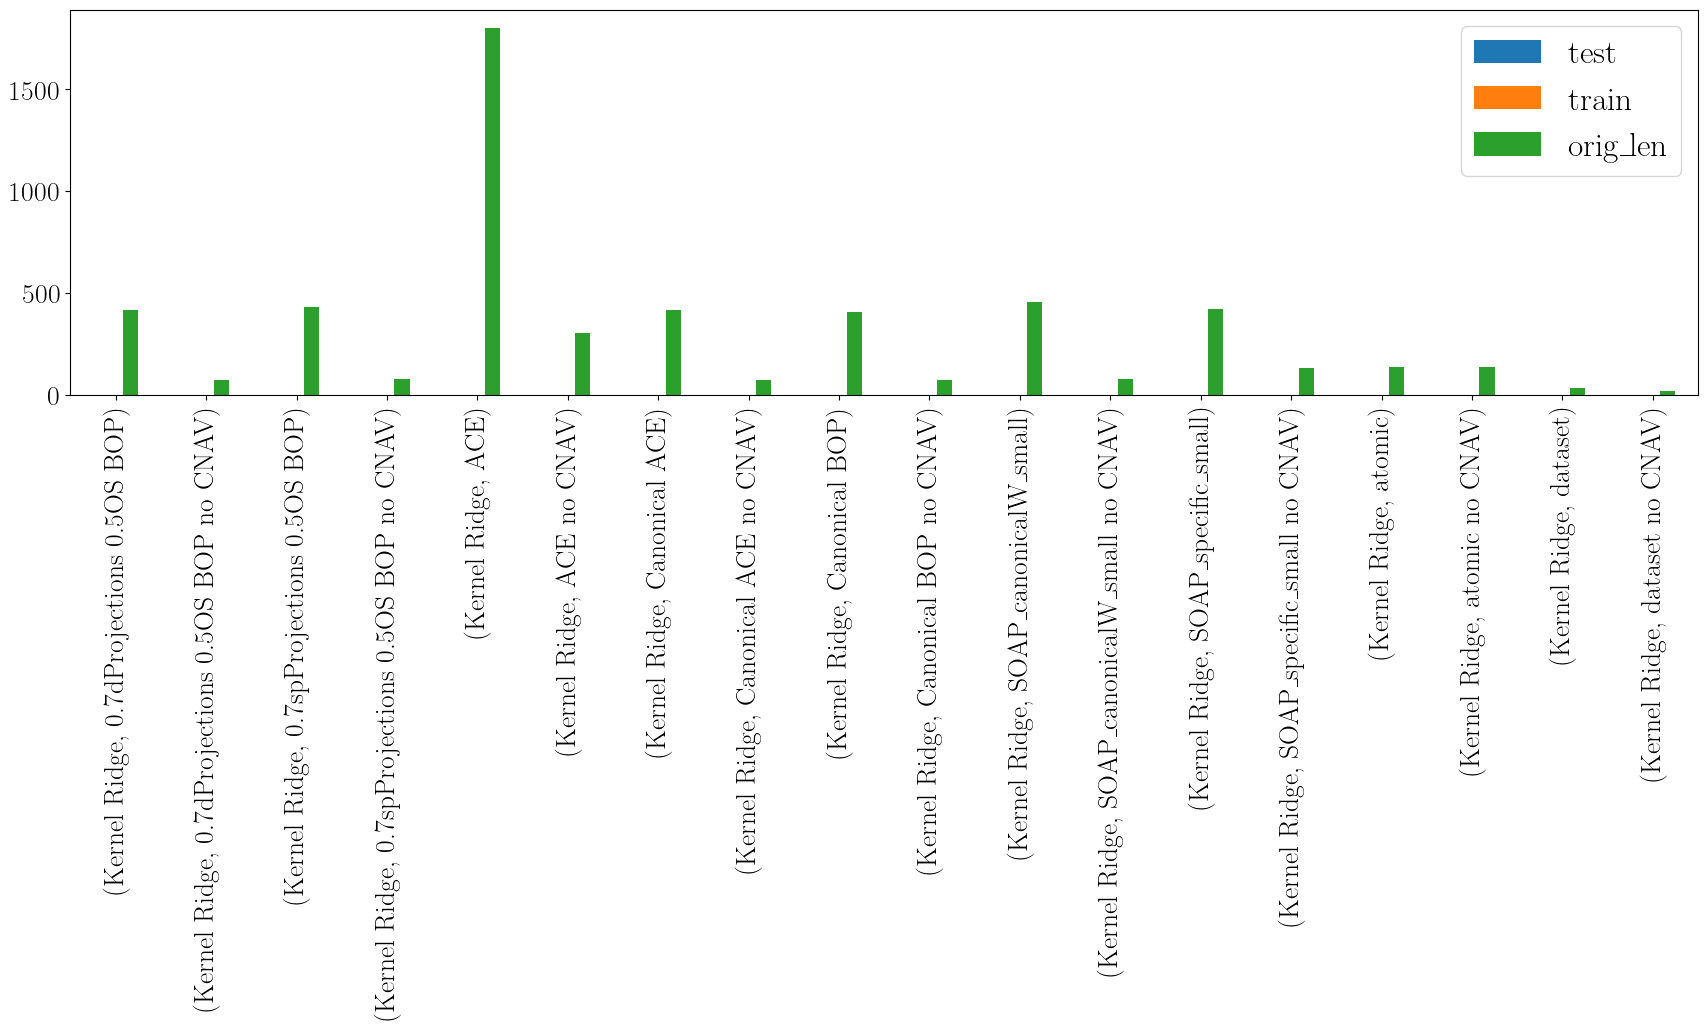

In [47]:
figwidth, figheight = plt.rcParams['figure.figsize']
OptimizedScoresDF.plot.bar(figsize=[3*figwidth, figheight])

In [48]:
unstack = OptimizedScoresDF.unstack(level=0)

In [49]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

In [50]:
iwanttoplot

Index(['0.7dProjections 0.5OS BOP', '0.7dProjections 0.5OS BOP no CNAV',
       '0.7spProjections 0.5OS BOP', '0.7spProjections 0.5OS BOP no CNAV',
       'ACE', 'ACE no CNAV', 'Canonical ACE', 'Canonical ACE no CNAV',
       'Canonical BOP', 'Canonical BOP no CNAV', 'SOAP_canonicalW_small',
       'SOAP_canonicalW_small no CNAV', 'SOAP_specific_small',
       'SOAP_specific_small no CNAV', 'atomic', 'atomic no CNAV', 'dataset',
       'dataset no CNAV'],
      dtype='object')

In [51]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

In [52]:
xs = {
    'ACE' : 7,
    'BOP': 5,
    'SOAP': 6,
    'sequential encoding': 4,
    'canonical BOP': 3,
    'Canonical ACE': 2,
    'Canonical SOAP': 1,
    'atomic': 0
}

In [53]:
deltas = {
    'Kernel Ridge': 0.25,
    'Random Forest': 0,
    'MLP': -0.25
}

In [54]:
clean_label_map = {
    '.*spProjections.*BOP': 'sp BOP',
    '.*dProjections.*BOP': 'BOP',
    'SOAP_specific_small': 'SOAP', 
    'SOAP_canonicalW_small': 'Canonical SOAP',
    'dataset' : 'sequential encoding',
    'Canonical BOP': 'canonical BOP'
}
def clean_label(label):
    cleanedlabel = copy.copy(label)
    for pattern, cleanlabel in clean_label_map.items():
        cleanedlabel = re.sub(pattern, cleanlabel, cleanedlabel)
    return cleanedlabel
    

In [55]:
colors = {'Kernel Ridge': 'brown',
         'Random Forest': 'steelblue', 
          'MLP': 'mediumseagreen'}

In [56]:
def assign_x(label, debug=False):
    if debug:
        print(label)
    if label not in xs.keys():
        return None
    return xs[label]

In [57]:
test_scores_cnav = test_scores[~test_scores.index.str.contains('no CNAV')].copy()
test_scores_cnav['labels'] = test_scores_cnav.index.map(clean_label)
test_scores_nocnav = test_scores[test_scores.index.str.contains('no CNAV')].copy()
test_scores_nocnav['labels'] = test_scores_nocnav.index.map(clean_label).str.replace(' no CNAV', '')
test_scores_cnav['xs'] = test_scores_cnav.labels.map(assign_x)
test_scores_nocnav['xs'] = test_scores_nocnav.labels.map(assign_x)


In [58]:
test_scores_cnav

,Kernel Ridge,labels,xs
SOAP_canonicalW_small,0.159376,Canonical SOAP,1.0
atomic,0.154846,atomic,0.0
Canonical ACE,0.130151,Canonical ACE,2.0
Canonical BOP,0.096016,canonical BOP,3.0
dataset,0.073857,sequential encoding,4.0
0.7spProjections 0.5OS BOP,0.068673,sp BOP,NaN
SOAP_specific_small,0.047294,SOAP,6.0
0.7dProjections 0.5OS BOP,0.023451,BOP,5.0
ACE,0.019241,ACE,7.0


In [59]:
xticks = [value for key, value in xs.items() ]

In [60]:
xlabels = [key for key, value in xs.items()]

In [61]:
{key: 2*x for key, x in xs.items()}

{'ACE': 14,
 'BOP': 10,
 'SOAP': 12,
 'sequential encoding': 8,
 'canonical BOP': 6,
 'Canonical ACE': 4,
 'Canonical SOAP': 2,
 'atomic': 0}

In [62]:
{key: 2*d+0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.75, 'Random Forest': 0.25, 'MLP': -0.25}

In [63]:
{key: 2*d-0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.25, 'Random Forest': -0.25, 'MLP': -0.75}

In [64]:
renamed_test_scores_nocnav = test_scores_nocnav.copy()

In [65]:
renamed_test_scores_nocnav.index = renamed_test_scores_nocnav.index.str.replace(' no CNAV','')

In [66]:
ratios = {}
for model in ['Kernel Ridge', 'MLP', 'Random Forest']:
    ratios[model] = (test_scores_cnav[model]/renamed_test_scores_nocnav[model])[renamed_test_scores_nocnav.index]

KeyError: 'MLP'

In [ ]:
from matplotlib.patches import FancyArrowPatch, FancyArrow
from matplotlib.lines import Line2D

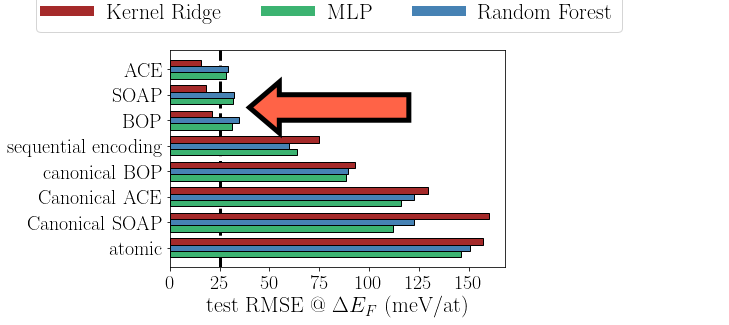

In [ ]:
verts=[(-0.25,-2),(0.25,-2),(0.25,2),(-0.25,2),(-0.25,-2)]
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight))#, sharey=True)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][ratios[model].index]+m*deltas[model],#+d, 
        test_scores_cnav[model][ratios[model].index].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=len(models),
    loc=(0.05, 0.9),
    fontsize = 22
)
fancyarrow = FancyArrowPatch((120, 10.7),(40,10.7), mutation_scale=100, facecolor='tomato', linewidth=5)
fancyarrow = FancyArrow(120, 11,-80,0,width=2, head_length=15, head_width=4, length_includes_head=True, facecolor='tomato', linewidth=5)
axs.add_patch(fancyarrow)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_CNAV_only.pdf'), bbox_inches='tight')

In [ ]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [ ]:
selection = ~(test_scores_cnav.index.str.contains('SOAP_canonical') | test_scores_cnav.index.str.contains('Canonical ACE'))

In [ ]:
test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])

/tmp/ipykernel_2371033/903731865.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])

In [ ]:
test_scores_cnav[selection]

,Kernel Ridge,MLP,Random Forest,labels,xs
atomic,0.157243,0.146035,0.150437,atomic,0.0
Canonical BOP,0.093085,0.088513,0.089620,canonical BOP,1.0
dataset,0.074732,0.064068,0.059716,sequential encoding,2.0
0.7spProjections 0.5OS BOP,0.025133,0.037158,0.038859,sp BOP,NaN
0.7dProjections 0.5OS BOP,0.021383,0.031157,0.034670,BOP,3.0
SOAP_specific_small,0.018157,0.031860,0.032118,SOAP,4.0
ACE,0.015711,0.028454,0.029258,ACE,5.0


In [ ]:
xlabels = [key for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key]

In [ ]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

In [ ]:
selection

array([False,  True, False,  True,  True,  True,  True,  True,  True])

In [ ]:
xs = {key: value-2 if value > 2 else value for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key}

In [ ]:
xs

{'ACE': 5,
 'BOP': 3,
 'SOAP': 4,
 'sequential encoding': 2,
 'canonical BOP': 1,
 'atomic': 0}

In [ ]:
xticks = [value for key, value in xs.items()]

In [ ]:
xticks

[5, 3, 4, 2, 1, 0]

In [ ]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

In [ ]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [ ]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

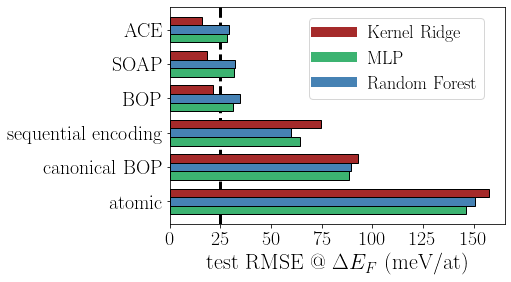

In [ ]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][selection]+m*deltas[model],#+d, 
        test_scores_cnav[model][selection].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=1, #len(models),
    loc='center', #(0.75, 0.75),
    bbox_to_anchor=(0.65, 0.7),
    fontsize = 18
)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'Figure_{dataset}_CNAV_only.pdf'), bbox_inches='tight')

In [ ]:
ratios['Kernel Ridge'].drop(['atomic', '0.7spProjections 0.5OS BOP',  'SOAP_canonicalW_small', 'Canonical ACE'], inplace=True)

In [ ]:
ratios.keys()

dict_keys(['Kernel Ridge', 'MLP', 'Random Forest'])

In [ ]:
ratios['MLP'].drop(['atomic', '0.7spProjections 0.5OS BOP',  'SOAP_canonicalW_small', 'Canonical ACE'], inplace=True)

In [ ]:
ratios['Random Forest'].drop(['atomic', '0.7spProjections 0.5OS BOP',  'SOAP_canonicalW_small', 'Canonical ACE'], inplace=True)

In [ ]:
xlabels[:-1]

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP']

In [ ]:
xticks[:-1]

[5, 3, 4, 2, 1]

In [ ]:
verts

[(-0.25, -2), (0.25, -2), (0.25, 2), (-0.25, 2), (-0.25, -2)]

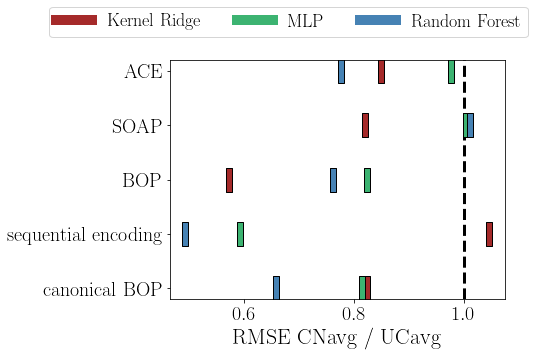

In [ ]:
verts=[(-0.5,-2),(0.5,-2),(0.5,2),(-0.5,2),(-0.5,-2)]
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(1,1, figsize=(figwidth,1.1*figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
for model in ['Kernel Ridge', 'MLP', 'Random Forest']: #, 'Random Forest', 'MLP']:
    axs.scatter(
        ratios[model], #.drop('atomic'),#test_scores_cnav[model]/renamed_test_scores_nocnav[model], 
        m*test_scores_cnav['xs'][ratios[model].index], #.drop('atomic').index], 
        color = colors[model],
        marker=path,
        s=600,
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
axs.set_xlabel(r'RMSE CNavg / UCavg')
axs.set_yticks([m*x for x in xticks[:-1]])
axs.set_yticklabels(xlabels[:-1])
fig.legend(
    handles,
    models, #+['no CNAV'],
    ncol=len(models),
    loc='center',
    bbox_to_anchor=(0.4, 1),
    fontsize = 18

)
axs.axvline(1, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'Figure_{dataset}_CNAV_vs_noCNAV.pdf'), bbox_inches='tight')

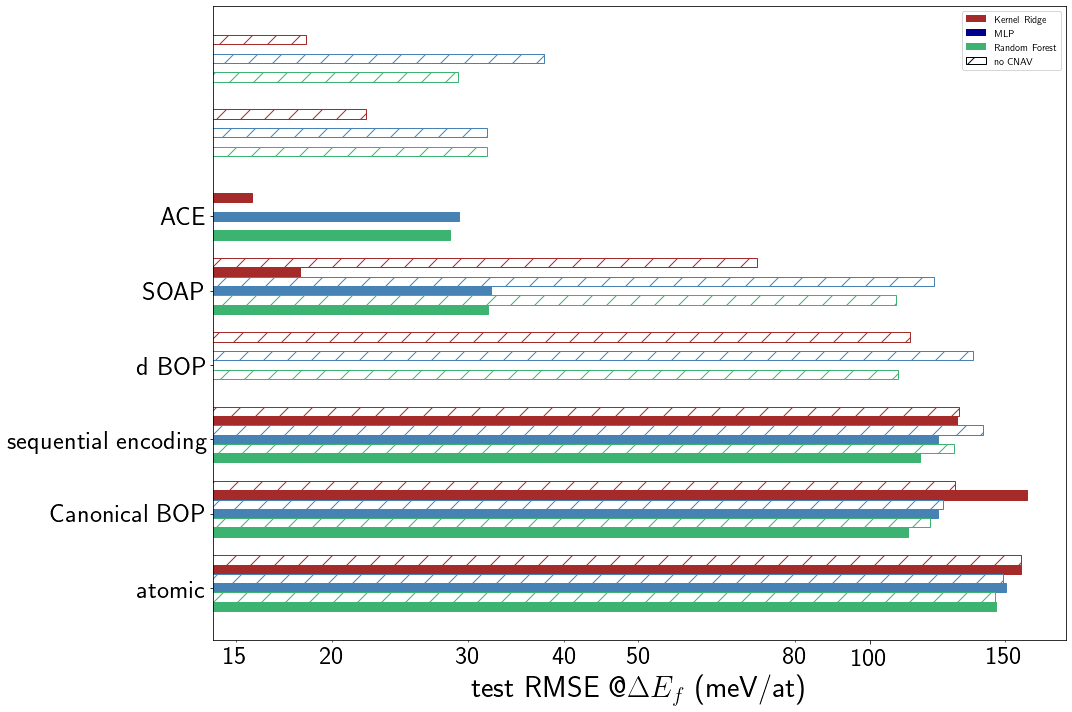

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
m = 2
d = 0.25
w = d
for model in ['Kernel Ridge', 'Random Forest', 'MLP']:
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
#        linewidth = 5
    )
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
        edgecolor=colors[model],
#        linewidth=5
    )
    ax.barh(
        m*test_scores_cnav['xs'].values+m*deltas[model],
        test_scores_cnav[model].values*1000, w,
        color = colors[model],
        edgecolor=colors[model],
#        linewidth=5,
#        zorder = 1
    )
ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_yticks([m*x for x in xticks])
ax.set_yticklabels(xlabels)
plt.legend(
    [Patch(facecolor='brown'),
     Patch(facecolor='darkblue'),
     Patch(facecolor='mediumseagreen'), 
     Patch(facecolor=(1,1,1,0.5), hatch='/', ec='black')
    ],
    models+['no CNAV'],
    ncol=1,
)
fig.tight_layout()
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_OptimalRegresorComparison.pdf'))